In [50]:

import os
import pandas as pd
import numpy as np
import networkx as nx 
import matplotlib.pyplot as plt
import torch
from networkx.algorithms.community import greedy_modularity_communities, modularity


In [23]:
def clean_gt_file_names(importance_ranking):

    """ Gets torch files of ground truth and replaces any old twitter
        usernames with the new ones to match the df_data """

    # Load the DataFrame with member data
    members = pd.read_csv('raw_data/raw_data/all_congress_members.csv')

    # Fill NA values in 'new_twitter_name' with values from 'twitter_name'
    members['new_twitter_name'] = members['new_twitter_name'].fillna(members['twitter_name'])

    # Create a dictionary mapping from the old Twitter names to the new Twitter names
    name_mapping = dict(zip(members['twitter_name'], members['new_twitter_name']))

    # Initialize a new dictionary to hold the updated importance ranking
    updated_importance_ranking = {}

    # Update the dictionary keys
    for old_name, value in importance_ranking.items():
        # Get the new Twitter name if available, otherwise keep the old name
        new_name = name_mapping.get(old_name, old_name)
        updated_importance_ranking[new_name] = value

    # Assign the updated dictionary back to importance_ranking
    return updated_importance_ranking

# Print the updated importance ranking to check
# importance_ranking = torch.load('01_normalized_congress_member_to_affiliation_score.pth')


In [24]:
def build_bipartite_network(df_data):

    """ Builds directed network using politicians and their followings as nodes
    and directed edges based on if one node follows the other. Used for finding importance
    of websites to filter network """

    G = nx.DiGraph()

    # Add edges based on the politicians and the people they follow
    for _, row in df_data.iterrows():
        politician = row['current_twitter_name']
        following_list = row['following']  # List of people the politician follows
        
        # Add the politician as a node
        G.add_node(politician, party=row['party'])
        
        # Add edges for each person the politician follows
        for followee in following_list:
            G.add_node(followee)  # Add the followed account as a node
            G.add_edge(politician, followee)  # Directed edge from politician to followed account
    
    return G

In [33]:
def read_data(num_nodes=-1):

    """ Reads data of politician, their party and who they follow into df_data """

    members = pd.read_csv('raw_data/raw_data/all_congress_members.csv')
    members['current_twitter_name'] = members['new_twitter_name'].fillna(members['twitter_name'])

    df_data = pd.DataFrame()
    df_data[['current_twitter_name','party']] = members[['current_twitter_name','party']].copy()
    if num_nodes != -1:
        df_data = df_data.head(num_nodes)

    following_data = []
    
    for twitter_name in df_data['current_twitter_name']:
        filename = f"twitterExport_{twitter_name}_Following.csv"
        filepath = os.path.join('raw_data/raw_data/following_data_raw', filename)

        if os.path.exists(filepath):
            followed_users = pd.read_csv(filepath)['user_name'].tolist()
        else:
            followed_users = []
        
        following_data.append(followed_users)

    df_data['complete_following'] = following_data
    df_data = df_data[df_data['complete_following'].apply(lambda x: x != [])]

    # Convert the list of all current twitter names to a set for faster lookup
    current_names_set = set(df_data['current_twitter_name'].values)

    # Filter out following names that also appear in df_data['current_twitter_name']
    filtered_following_data = []
    for follow_list in df_data['complete_following']:
        filtered_list = [name for name in follow_list if name not in current_names_set]
        filtered_following_data.append(filtered_list)

    df_data['following'] = filtered_following_data
    df_data = df_data[df_data['following'].apply(lambda x: x != [])]
    
    republican_df = df_data[df_data['party'] == "R"]
    democratic_df = df_data[df_data['party'] == "D"]
    importance_ranking = clean_gt_file_names(torch.load('01_normalized_congress_member_to_affiliation_score.pth'))
    df_data['affiliation_score'] = df_data['current_twitter_name'].map(importance_ranking)

    return df_data, republican_df, democratic_df

In [34]:
def degree_lower_2_remover(df_data,G_bipartite):
    degree_centrality = {node: G_bipartite.degree(node) for node in G_bipartite.nodes()}
    # Filtering nodes based on threshold
    filtered_followees = {node for node, score in degree_centrality.items() if score >= 2}
    df_data['following'] = df_data['following'].apply(lambda followings: [f for f in followings if f in filtered_followees])


In [35]:
def classify_communities(alignment):
    ratio_list = []
    community_label = {}
    for community_id, parties_total in alignment.items():
        ratio = parties_total['R']/(parties_total['R']+parties_total['D'])
        ratio_list.append(ratio)

    if ratio_list[0]>ratio_list[1]:
        Republican = 1
        Democrat = 2
    else:
        Republican = 2
        Democrat = 1

    community_label[Republican] = 'Republican'
    community_label[Democrat] = 'Democrat' 
    # print(ratio_list, community_label)
    return community_label
    

In [36]:
def merge_n_communities_by_edge_count(G, communities, no_communities):
    """Merge a list of communities into exactly n_communities based on the edge counts between them.

    Args:
        G (networkx.Graph): The graph from which the communities are derived.
        communities (list of set): List of communities to merge, where each community is a set of nodes.
        no_communities (int): Desired number of communities after merging.

    Returns:
        list of set: Communities merged based on edge connectivity.
    """
    
    if len(communities) < no_communities:
        raise ValueError("The number of initial communities must be at least equal to the desired number of final communities.")

    # Convert frozensets or other iterables to sets if necessary
    communities = [set(community) for community in communities]

    # Sort communities by size in descending order
    communities = sorted(communities, key=len, reverse=True)

    # Start with the largest communities as determined by 'no_communities'
    largest_communities = communities[:no_communities]
    remaining_communities = communities[no_communities:]

    # Function to count edges between two sets of nodes
    def count_edges_between(set1, set2):
        return sum(1 for node in set1 if set(G.neighbors(node)) & set2)

    # Merge remaining communities into the largest based on edge counts
    for community in remaining_communities:
        max_edges = -1
        best_target_idx = -1

        # Determine which of the largest communities this should merge with
        for i, large_community in enumerate(largest_communities):
            edge_count = count_edges_between(community, large_community)
            if edge_count > max_edges:
                max_edges = edge_count
                best_target_idx = i

        # Merge the community into the best matching largest community
        largest_communities[best_target_idx].update(community)
    return largest_communities


In [37]:
def apply_greedy_modularity_n_partitions(G, no_of_communities):
    """Applies greedy modularity community detection and merges results into two communities.

    Args:
        G (networkx.Graph): The graph on which to apply the community detection.

    Returns:
        tuple: Contains the two communities, party alignment, modularity of the partition, and community labels.
    """
    # Detect communities using greedy modularity maximization
    initial_communities = greedy_modularity_communities(G, cutoff=no_of_communities)

    # Merge communities into two
    if len(initial_communities) > no_of_communities:
        communities = merge_n_communities_by_edge_count(G, initial_communities, no_of_communities)
        # communities = merge_communities_into_two_by_edge_count(G, initial_communities)
        # communities = merge_communities_max_modularity(G, initial_communities)
        # communities = merge_into_two_communities(initial_communities)
    else:
        communities = [set(community) for community in initial_communities]

    # Calculate modularity for the two communities
    # try:
    mod_value = modularity(G, communities)
    # except:
    #     mod_value = 0
    # print(f"Modularity of the partition: {mod_value}")

    return communities, mod_value#alignment, mod_value, comm_labels


In [38]:
def political_alignment(G, communities):
    """
    Analyze alignment with political parties for a given set of communities.

    Args:
        G (networkx.Graph): The graph from which the communities are derived, with nodes having a 'party' attribute.
        communities (list of set): List of communities, where each community is a set of nodes.

    Returns:
        dict: Dictionary containing the political alignment of each community.
    """
    # Initialize an alignment dictionary for all communities
    alignment = {}
    for idx, community in enumerate(communities, start=1):
        # Initialize party counts for the current community
        alignment[idx] = {'R': 0, 'D': 0}
        for node in community:
            if 'party' in G.nodes[node]:  # Check if the 'party' attribute exists
                party = G.nodes[node]['party']
                if party in alignment[idx]:  # Increment the party count if it's either 'R' or 'D'
                    alignment[idx][party] += 1
                else:  # Optional: initialize other party labels dynamically
                    alignment[idx][party] = 1

    return alignment


In [42]:
def build_network(df_data, k, hits, weighted):

    """ Builds network of politicians, with edges between them if they share k followers """

    G = nx.Graph()
    
    # Add nodes
    names = df_data['current_twitter_name'].tolist()

    for _, row in df_data.iterrows():
        politician = row['current_twitter_name']        
        G.add_node(politician, party=row['party'])
    
    # Add edges based on shared following
    for i in range(len(df_data)):
        for j in range(i + 1, len(df_data)):
            # Get the sets of following of each politician
            # Uses the "important_following" column if we incorporate hits, otherwise defaults to the "following" column
            if hits:
                following_i = set(df_data.iloc[i]['important_following'])
                following_j = set(df_data.iloc[j]['important_following'])
            else:
                following_i = set(df_data.iloc[i]['following'])
                following_j = set(df_data.iloc[j]['following'])
            
            # Get the shared following
            shared_following = following_i.intersection(following_j)
            if len(shared_following) >= k:
                if weighted == False:
                    G.add_edge(names[i], names[j])
                else:
                    G.add_edge(names[i], names[j], weight=len(shared_following))
    
    return G

In [66]:
def build_link_path_bipartite(G, communities):
    """
    Create a bipartite network from a given graph where edges represent the shortest
    path lengths between nodes in two distinct communities.
    
    Parameters:
    - G (nx.Graph): The original graph from which to compute shortest paths.
    - community_a (set): A set of node identifiers belonging to community A.
    - community_b (set): A set of node identifiers belonging to community B.
    
    Returns:
    - B (nx.Graph): A bipartite graph with nodes from community A and B and
                    edges weighted by shortest path lengths between communities.
    """
    # Initialize a new graph for the bipartite network
    B = nx.Graph()
    community_a = communities[0]
    community_b = communities[1]
    # Calculate shortest paths and create edges in the bipartite network
    for node_a in community_a:
        for node_b in community_b:
            if nx.has_path(G, node_a, node_b):  # Ensure there is a path
                path_length = nx.shortest_path_length(G, source=node_a, target=node_b)
                B.add_edge(node_a, node_b, weight=path_length)

    return B

In [67]:
def visualise_graph(G, communities, spacing, title):

    """ Visualise graph coloured red and blue for R and D classed by louvain algorithm respectively """
    
    community1 = communities[0]
    plt.figure(figsize=(20, 15))
    node_colors = []
    for node in G.nodes():
        if node in community1:
            node_colors.append('red')
        else:
            node_colors.append('lightskyblue')

    pos = nx.spring_layout(G, k=spacing/np.sqrt(len(G.nodes())), iterations=20)
    nx.draw(
        G, pos=pos, with_labels=True, node_color=node_colors, node_size=2000, font_size=6
    )
    plt.title(title, fontsize=16)
    plt.show()
    

In [107]:
df_data, republican_df, democratic_df = read_data(-1)
G_bipartite = build_bipartite_network(df_data)
degree_lower_2_remover(df_data, G_bipartite)

In [108]:
G = build_network(df_data, 5, False, True)
communities, mod_value = apply_greedy_modularity_n_partitions(G, 2)

In [109]:
node_to_community = {}
for node in communities[0]:
    node_to_community[node] = 1
for node in communities[1]:
    node_to_community[node] = 2

In [110]:
B = build_link_path_bipartite(G, communities)

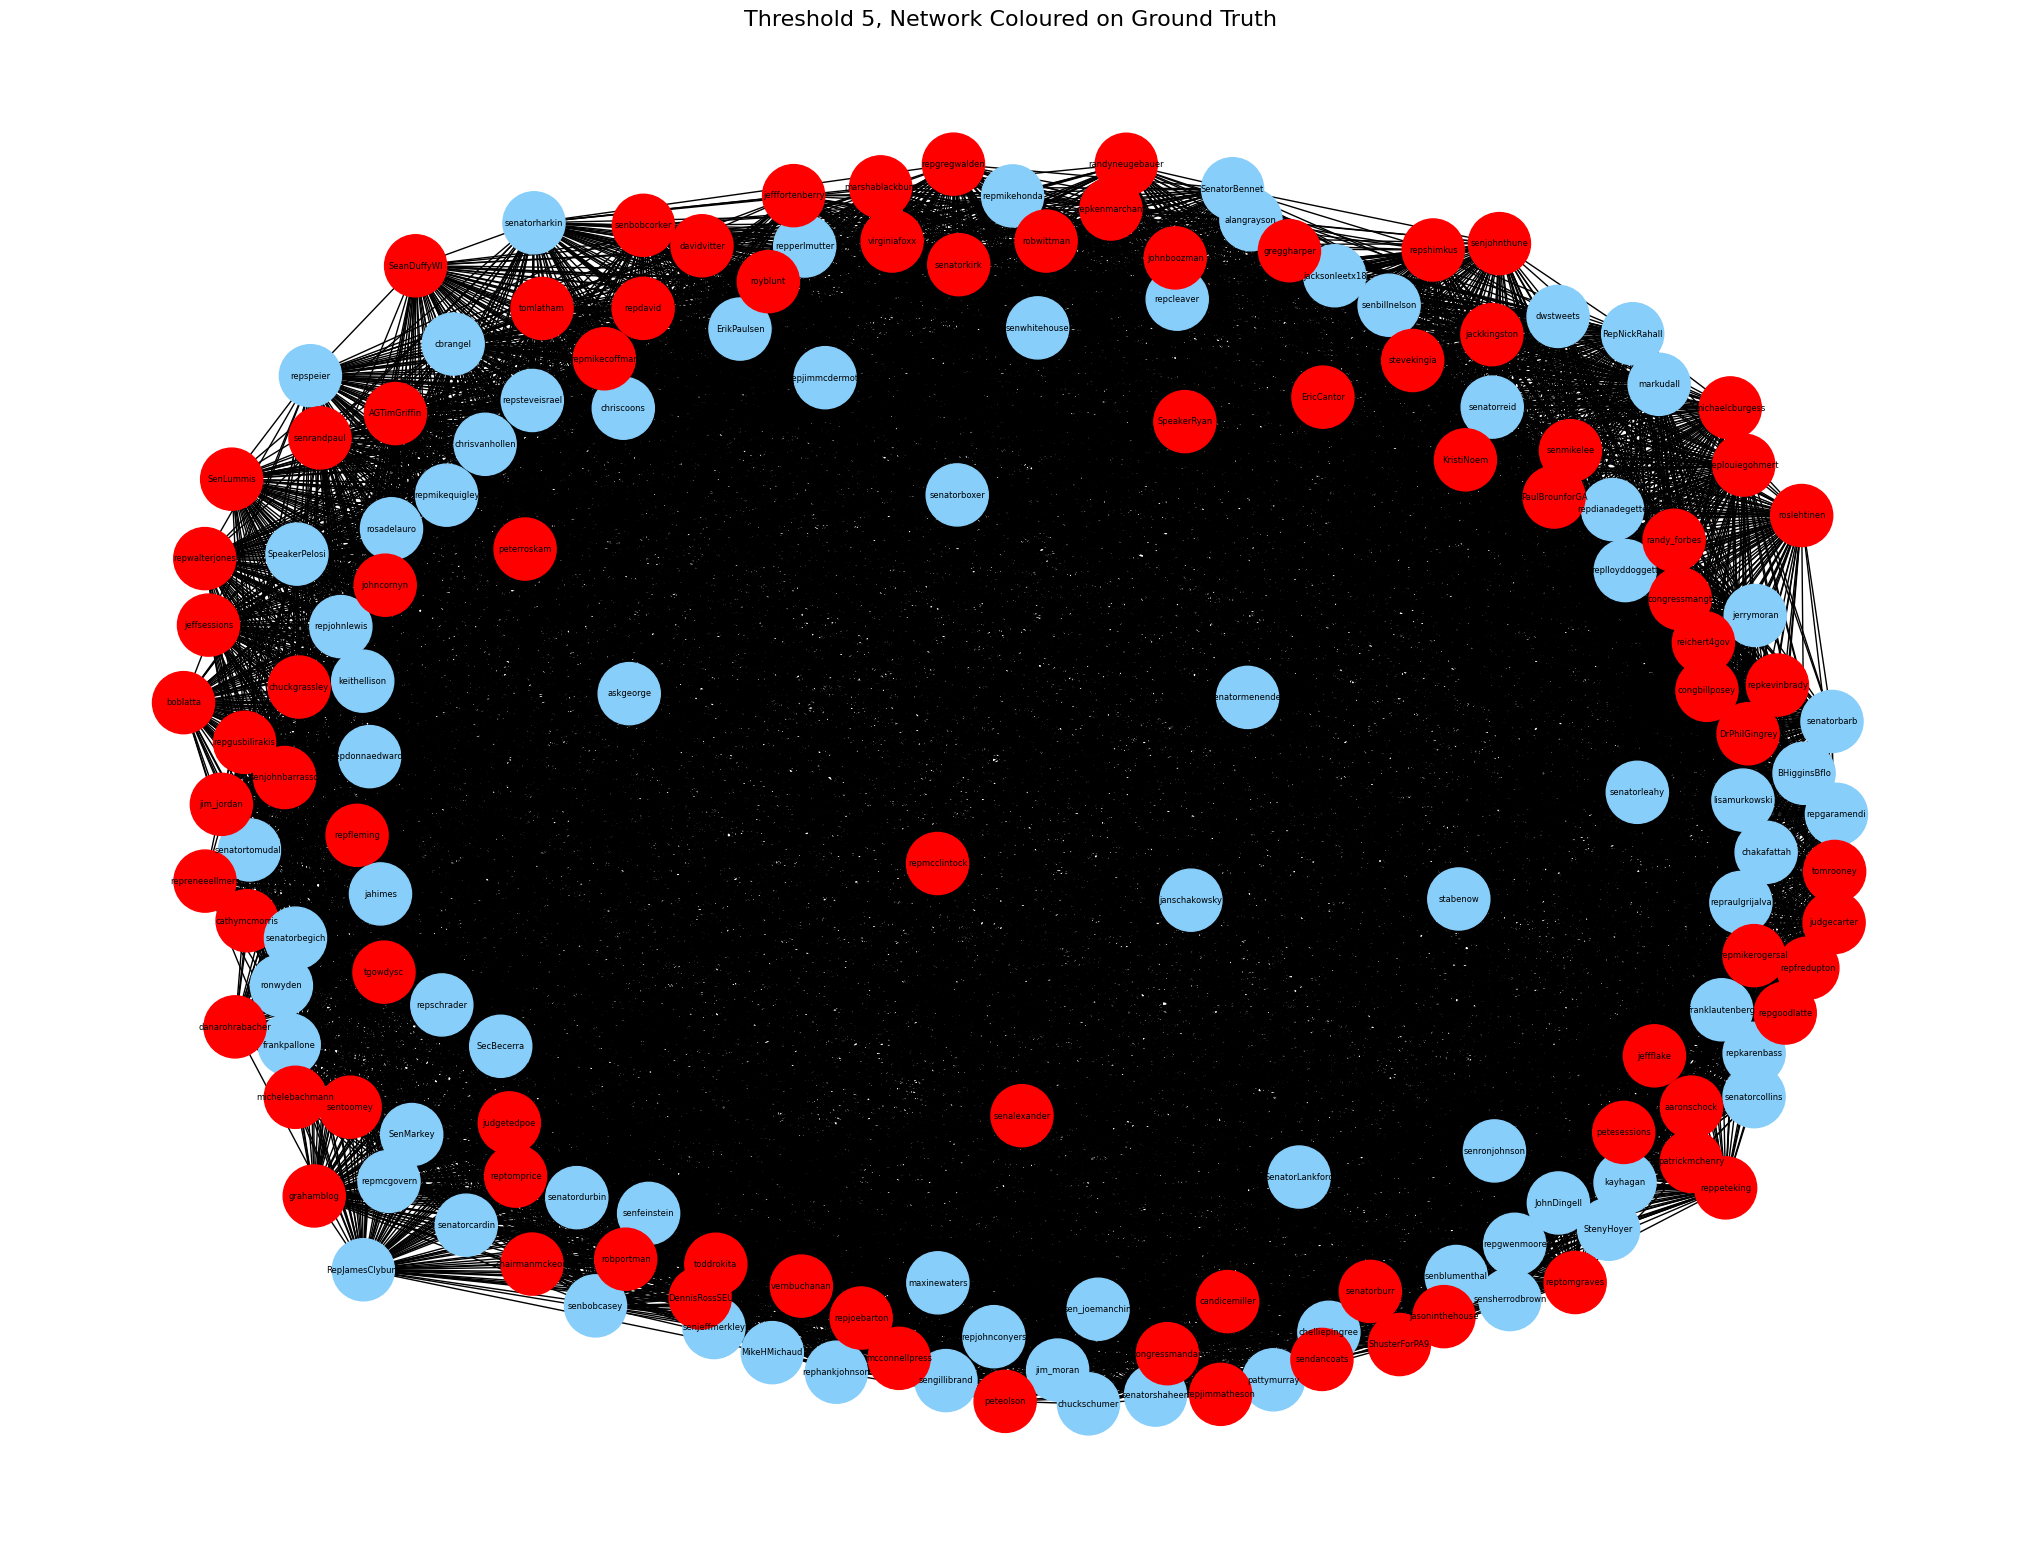

In [111]:
community_sets = [set(community) for community in communities]
title = "Threshold 5, Network Coloured on Ground Truth"
visualise_graph(B, community_sets, 35, title)

In [112]:
def filter_graph_by_edge_weight(graph, weight_threshold):
    """
    Remove edges from a graph where the edge weight exceeds a given threshold.
    
    Parameters:
    - graph (nx.Graph): The graph to be processed.
    - weight_threshold (float): The maximum allowable weight for edges to remain in the graph.
    
    Returns:
    - filtered_graph (nx.Graph): The graph with edges removed where weights exceed the threshold.
    """
    # Create a copy of the graph to preserve the original graph
    filtered_graph = graph.copy()

    # List of edges to remove
    edges_to_remove = [(u, v) for u, v, d in filtered_graph.edges(data=True) if d['weight'] > weight_threshold]

    # Remove the edges
    filtered_graph.remove_edges_from(edges_to_remove)

    return filtered_graph

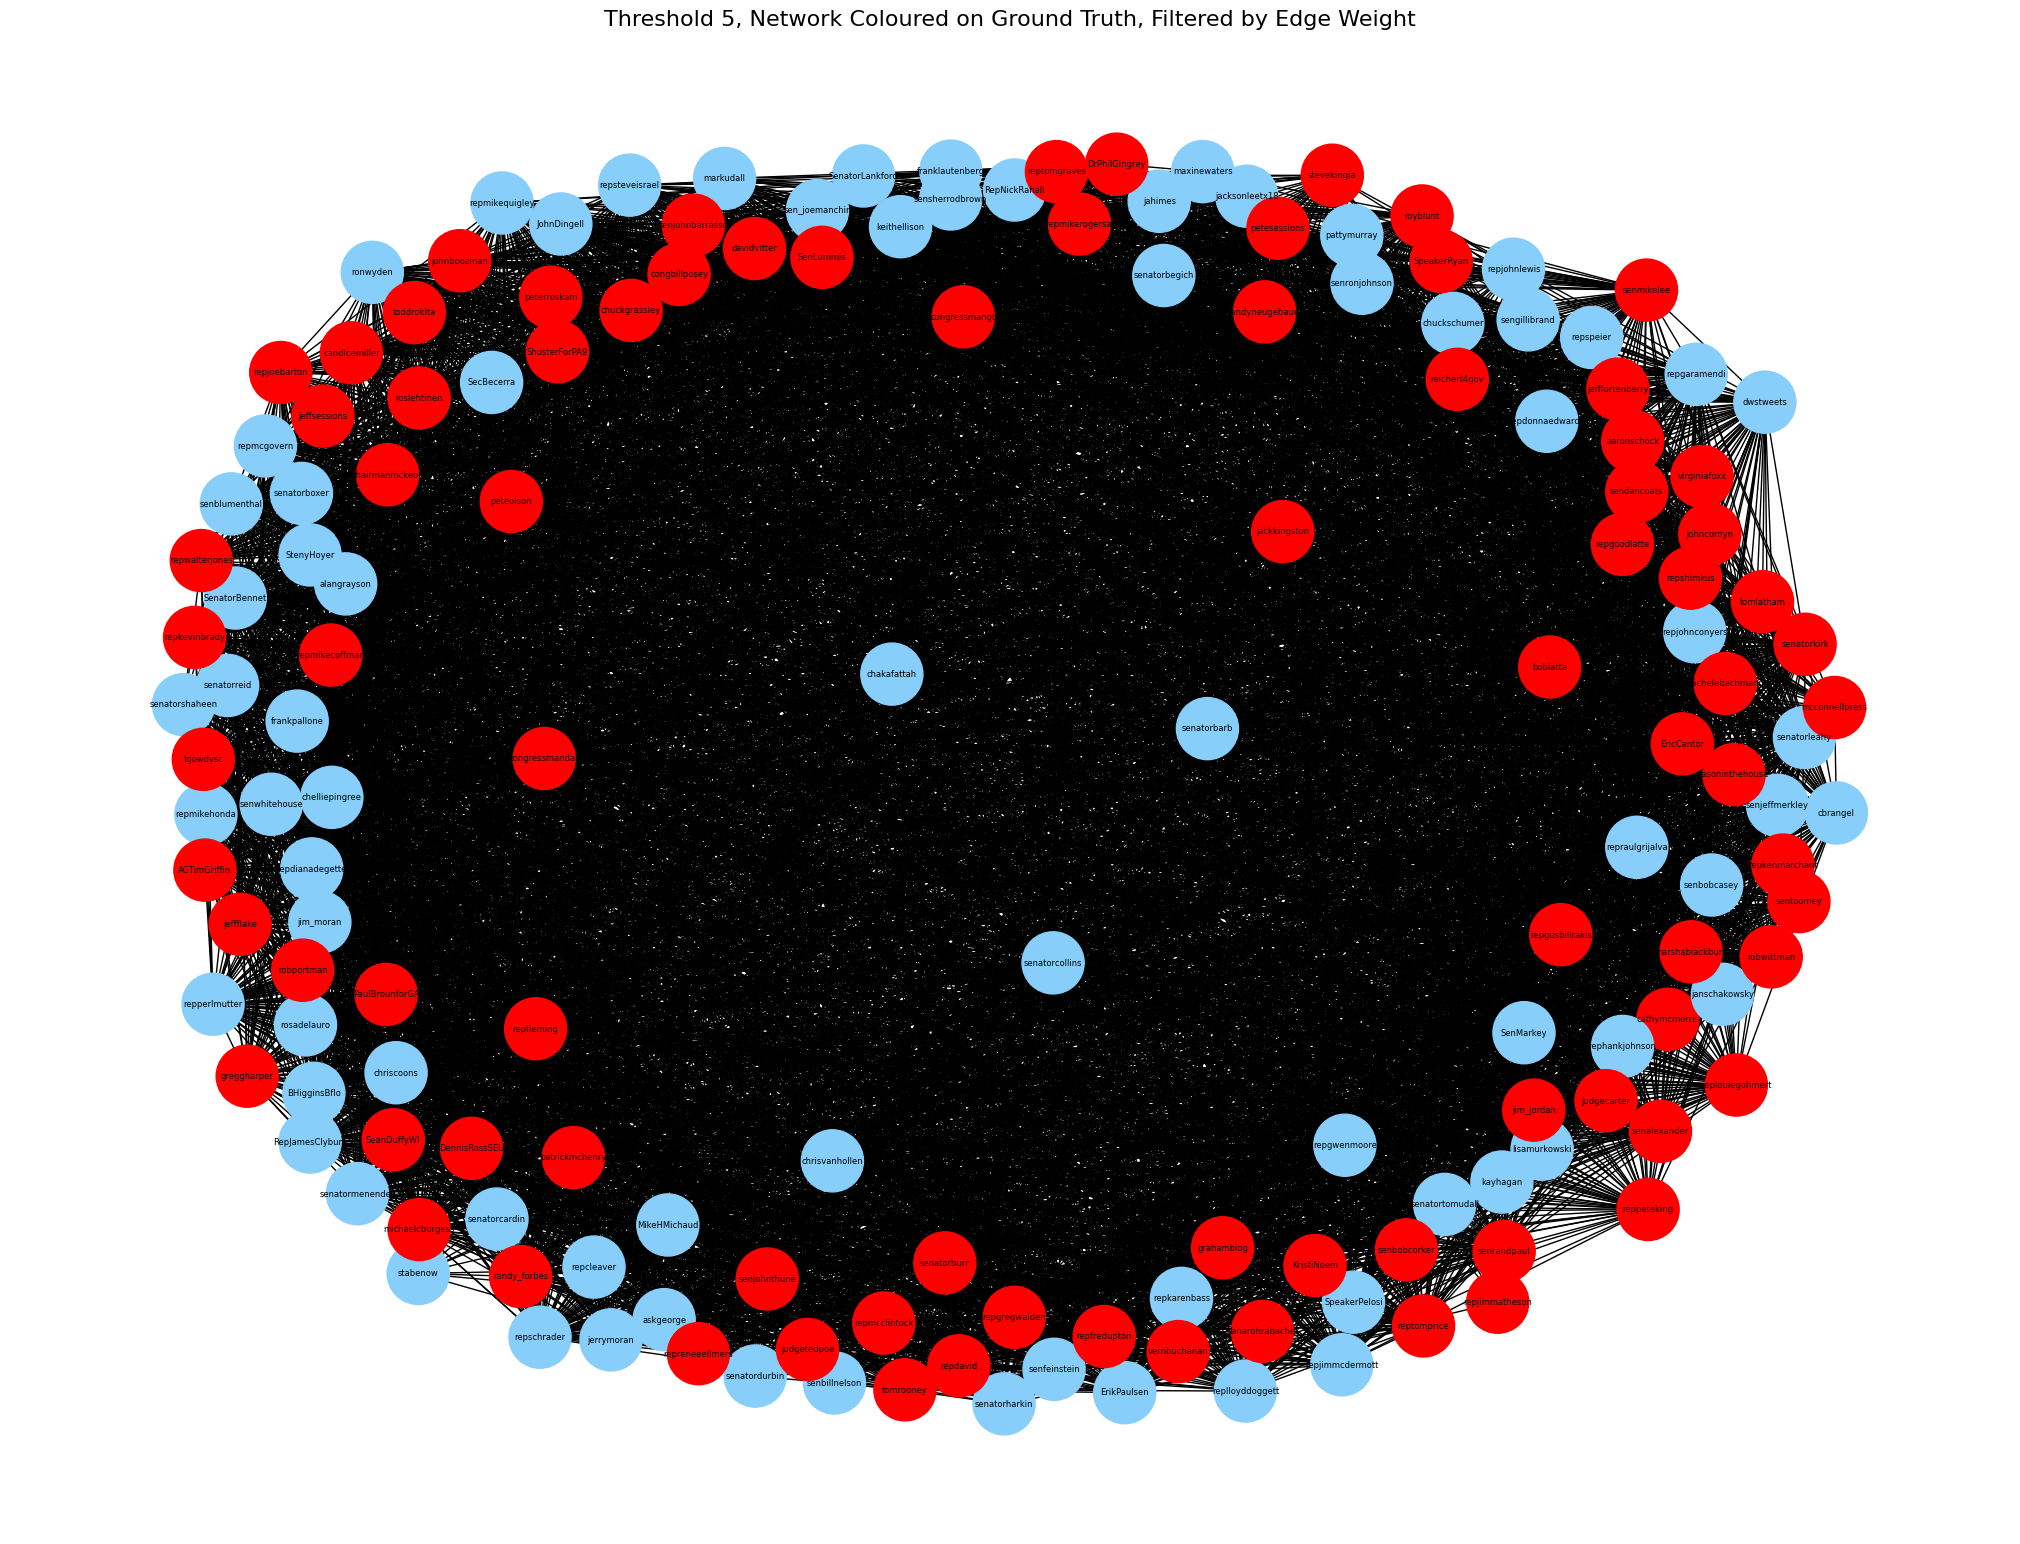

In [118]:
B_og = build_link_path_bipartite(G, communities)
B = filter_graph_by_edge_weight(B_og, 1)
visualise_graph(B, community_sets, 35, "Threshold 5, Network Coloured on Ground Truth, Filtered by Edge Weight")

In [119]:
# Get the number of edges in the graph
total_edges = B.number_of_edges()
print("Total number of edges in the graph:", total_edges)
total_edges = B_og.number_of_edges()
print("Total number of edges in the unfiltered graph:", total_edges)

Total number of edges in the graph: 5652
Total number of edges in the unfiltered graph: 6630


In [121]:
import seaborn as sns

def plot_edge_weight_distribution(G):
    """
    Plot the distribution of edge weights in a given NetworkX graph.
    
    Parameters:
    - G (nx.Graph): The graph from which to extract and plot edge weights.
    """
    # Extract edge weights into a list
    edge_weights = [data['weight'] for u, v, data in G.edges(data=True) if 'weight' in data]

    # Check if the list is not empty
    if not edge_weights:
        print("No weights found on edges in the graph.")
        return

    # Plotting the distribution of edge weights
    plt.figure(figsize=(10, 6))
    sns.histplot(edge_weights, kde=True, color='blue')  # You can choose to not use KDE (kernel density estimate)
    plt.title('Distribution of Edge Weights')
    plt.xlabel('Weight')
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()


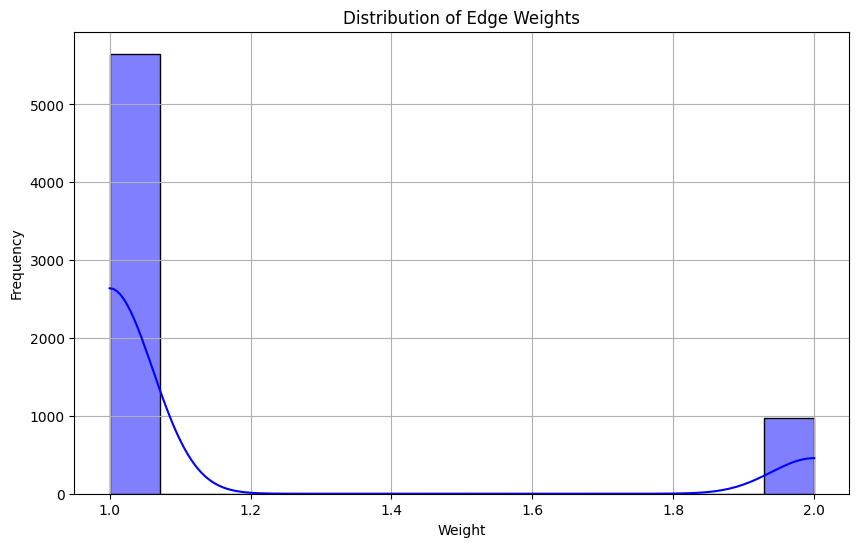

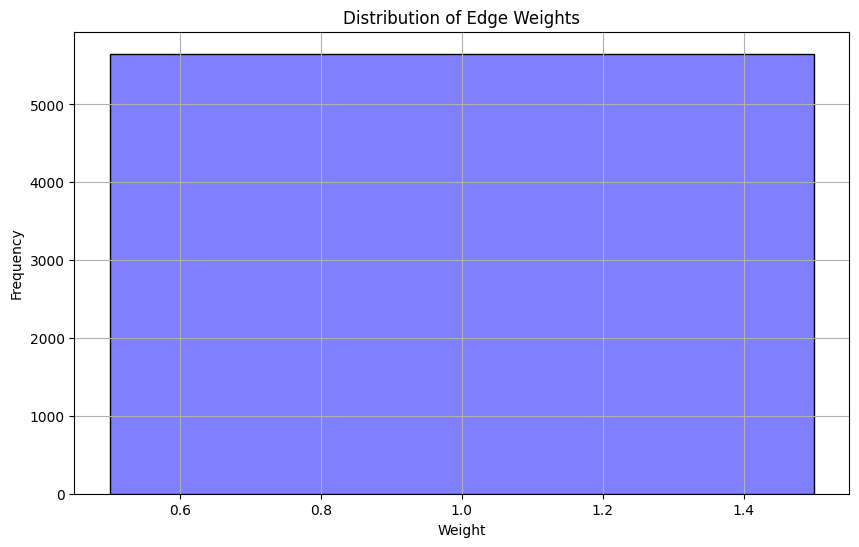

In [122]:
plot_edge_weight_distribution(B_og)
plot_edge_weight_distribution(B)
